## Exercise 5.3

In [2]:
import numpy as np
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize ,
                         poly)
from sklearn.model_selection import train_test_split
from functools import partial
from sklearn.model_selection import \
(cross_validate , KFold , ShuffleSplit)
from sklearn.base import clone
from ISLP.models import sklearn_sm

In [3]:
Auto = load_data('Auto')
Auto_train, Auto_valid = train_test_split(Auto, test_size=196, random_state=0)


In [5]:
hp_mm = MS(['horsepower'])
X_train = hp_mm.fit_transform(Auto_train)
y_train = Auto_train['mpg']
model = sm.OLS(y_train, X_train)
results = model.fit()

In [6]:
X_valid = hp_mm.transform(Auto_valid)
y_valid = Auto_valid['mpg']
valid_pred = results.predict(X_valid)
np.mean((y_valid - valid_pred)**2)

np.float64(23.616617069669893)

In [7]:
def evalMSE(terms, response, train , test):
    mm = MS(terms)
    X_train = mm.fit_transform(train)
    y_train = train[response]
    X_test = mm.transform(test)
    y_test = test[response]
    results = sm.OLS(y_train, X_train).fit()
    test_pred = results.predict(X_test)
    return np.mean((y_test - test_pred)**2)

MSE = np.zeros(3)
for idx, degree in enumerate(range(1, 4)):
    MSE[idx] = evalMSE([poly('horsepower', degree)], 'mpg',Auto_train, Auto_valid)
MSE

array([23.61661707, 18.76303135, 18.79694163])

In [8]:
Auto_train, Auto_valid = train_test_split(Auto, test_size=196, random_state=3)
MSE = np.zeros(3)
for idx, degree in enumerate(range(1, 4)):
    MSE[idx] = evalMSE([poly('horsepower', degree)], 'mpg',Auto_train, Auto_valid)
MSE

array([20.75540796, 16.94510676, 16.97437833])

In [9]:
hp_model = sklearn_sm(sm.OLS, MS(['horsepower']))
X, Y = Auto.drop(columns=['mpg']), Auto['mpg']
cv_results = cross_validate(hp_model, X, Y, cv=Auto.shape[0])
cv_err = np.mean(cv_results['test_score'])
cv_err

np.float64(24.231513517929226)

In [10]:
cv_error = np.zeros(5)
H = np.array(Auto['horsepower'])
M = sklearn_sm(sm.OLS)
for i, d in enumerate(range(1,6)):
    X = np.power.outer(H, np.arange(d+1))
    M_CV = cross_validate(M, X, Y, cv=Auto.shape[0])
    cv_error[i] = np.mean(M_CV['test_score'])
cv_error

array([24.23151352, 19.24821312, 19.33498406, 19.4244303 , 19.03321527])

In [11]:
A = np.array([3, 5, 9])
B = np.array([2, 4])
np.add.outer(A, B)

array([[ 5,  7],
       [ 7,  9],
       [11, 13]])

In [12]:
cv_error = np.zeros(5)
cv = KFold(n_splits=10, shuffle=True, random_state=0) # use same splits for each degree
for i, d in enumerate(range(1,6)):
    X = np.power.outer(H, np.arange(d+1))
    M_CV = cross_validate(M, X, Y, cv=cv)
    cv_error[i] = np.mean(M_CV['test_score'])
cv_error

array([24.20766449, 19.18533142, 19.27626666, 19.47848402, 19.13718373])

In [13]:
validation = ShuffleSplit(n_splits=1, test_size=196, random_state=0)
results = cross_validate(hp_model,Auto.drop(['mpg'], axis=1), Auto['mpg'], cv=validation);
results['test_score']


array([23.61661707])

In [14]:
validation = ShuffleSplit(n_splits=10, test_size=196, random_state=0)
results = cross_validate(hp_model,Auto.drop(['mpg'], axis=1), Auto['mpg'], cv=validation);
results['test_score'].mean(), results['test_score'].std()

(np.float64(23.802232661034168), np.float64(1.4218450941091916))

## Exercise 8

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ISLP as plot

In [15]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

x - 2x^2 + noise

there are 100 datapoints so n = 100 and there are two predictors x and x^2 so p = 2

<Axes: xlabel='x', ylabel='y'>

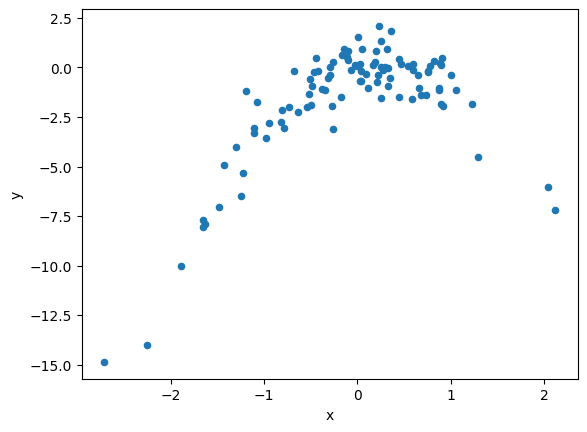

In [21]:
df = pd.DataFrame({'x': x,'y': y})
df.plot.scatter(x ='x', y ='y')


the data is clumped at the top of the curve, the equation is clearly visible in the data despite the noise.

In [29]:
cv_error = np.zeros(10)
M = sklearn_sm(sm.OLS)
for i, d in enumerate(range(1,11)):
    mm = MS([poly('x',degree=d)])
    X = mm.fit_transform(df)
    M_CV = cross_validate(M, X, y, cv=df.shape[0])
    cv_error[i] = np.mean(M_CV['test_score'])
cv_error

array([  6.63302984,   1.12293686,   1.30179655,   1.33239427,
         1.50709269,   1.00127442,   1.12597417,   1.16668296,
         9.98679073, 630.5610735 ])

In [26]:
dftrain, dfvalid = train_test_split(df, test_size=50, random_state=0)
MSE = np.zeros(5)
for idx, degree in enumerate(range(1, 6)):
    MSE[idx] = evalMSE([poly('x', degree)], 'y',dftrain, dfvalid)
MSE

array([9.23176742, 1.36765024, 2.3927729 , 2.30701253, 6.50714435])

In [27]:
dftrain, dfvalid = train_test_split(df, test_size=50, random_state=4)
MSE = np.zeros(5)
for idx, degree in enumerate(range(1, 6)):
    MSE[idx] = evalMSE([poly('x', degree)], 'y',dftrain, dfvalid)
MSE

array([ 8.09129301,  0.91232401,  0.96109782,  2.17036325, 45.24141689])

because each split is with different data which will change the MSE.

the second model had the best mean standard error. it matches up because the equations highest order predictor (x^2) is exactly that.